***Transformer Version of the chatbot***

Below code provide the necessary installations required for the program to run and execute sucessfully. List of the installations is



*   sentence-transformers - library for pre-trained models for generating sentence embeddings
*   faiss-cpu - it ia a facebook AI library for fast similarity search
*   transformers - It is a hugging face library for transformer models like BERT, T5
*   accelerate - it is a utility for optimized training
*   bitsandbytes - 8/4 bit optimizers for large models.
*   nltk - NLP tools  for text processing tasks
*   bert-score - evaluation metric for comparing text similarity using BERT embeddings


In [1]:
!pip install sentence-transformers faiss-cpu transformers accelerate bitsandbytes nltk bert-score

Below code imports the necessary libraries used throughout the project


*   os- for input/output operations like accessing local directory, file etc
*   SentenceTransformer- for semantics embeddings
*   faiss- for vectors similarity search
*   numpy-for numerical operations
*   T5ForConditionalGeneration- text-text generation tasks
*   T5Tokenizer- text-text generation tasks
*   AutoTokenizer- loaing casual language models
*   AutoModelForCausalLM-- loaing casual language models
*   pipeline-
*   nltk,nltk.download('punkt') - tokenizer word/sentence  
*   time - time operations
*   accuracy_score - evaluation metric
*   sentence_bleu - bleu score for text generation quality
*   SmoothingFunction - provide smoothing methods so that even if there is not a perfect match score is assigned based on partial match of text or semantic
*   bert_score  - to compute semantic similarity scores using bert embeddings.
*   json - json parsing etc

In [2]:
import os
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from transformers import T5ForConditionalGeneration, T5Tokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import nltk
nltk.download('punkt')
# nltk.download('punkt_tab') # This download is not necessary and might cause issues
from transformers.modeling_utils import PreTrainedModel # Import PreTrainedModel explicitly

import time
from sklearn.metrics import accuracy_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score
import json
import requests

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#Part-1 Data Preprocessing and model training
**1.1 Data Collection**

In [3]:
corpus_dbs = []
folder_path_training = "/content/Research-Chatbot"

github_url_training = [ "https://raw.githubusercontent.com/sandeepkumar-84/DBS/refs/heads/dbs_applied_research_project_v1/AppliedResearch/Working%20v1/Transformer%20Version/Transformer_Training_DataSet-1.txt",
                       "https://raw.githubusercontent.com/sandeepkumar-84/DBS/refs/heads/dbs_applied_research_project_v1/AppliedResearch/Working%20v1/Transformer%20Version/Transformer_Training_DataSet-2.txt"
                       ]

test_data_path = "https://raw.githubusercontent.com/sandeepkumar-84/DBS/refs/heads/dbs_applied_research_project_v1/AppliedResearch/Working%20v1/Transformer%20Version/Transformer_Test_DataSet.json"

def load_from_github(urls):
    loaded_flag = False
    for url in urls:
        try:
            response = requests.get(url)
            if response.status_code == 200:
                content = response.text
                paras = [para.strip() for para in content.split('\n') if len(para.strip()) > 50]
                corpus_dbs.extend(paras)
                print(f"Loaded {len(paras)} paragraphs from {url}")
                loaded_flag = True
            else:
                print(f"failed to fetch {url}")
        except Exception as e:
            print(f"error reading from GitHub file {url}: {e}")
    return loaded_flag

def load_from_local(folder_path):
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        if file_path.endswith(".txt"):
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    paras = [para.strip() for para in content.split('\n') if len(para.strip()) > 50]
                    corpus_dbs.extend(paras)
                    print(f"Loaded {len(paras)} paragraphs from {file_path}")
            except Exception as e:
                print(f"error reading local file {file_path}: {e}")


load_from_local(folder_path_training)

#if not load_from_github(github_url_training):
 #   load_from_local(folder_path_training)

print(f"Loaded {len(corpus_dbs)} paragraphs.")


Loaded 348 paragraphs from /content/Research-Chatbot/Transformer_Training_DataSet-2.txt
Loaded 2618 paragraphs from /content/Research-Chatbot/Transformer_Training_DataSet-1.txt
Loaded 2966 paragraphs.


**1.2 Visualization**

below code plot the corpus as wordcloud

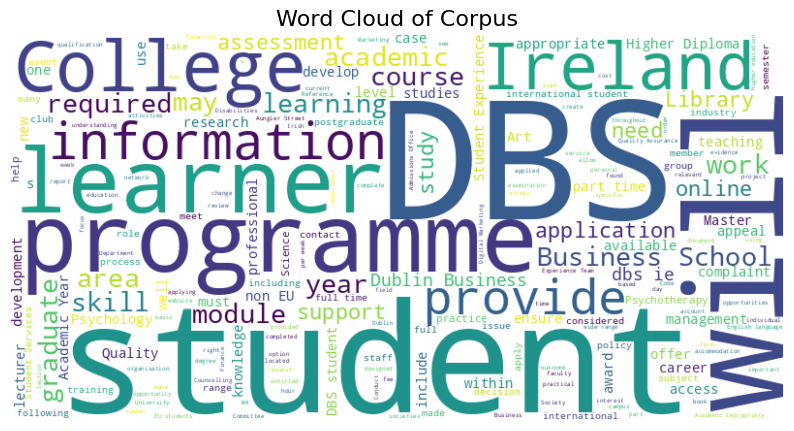

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text_data = " ".join(corpus_dbs)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text_data)


plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Corpus", fontsize=16)
plt.show()


**1.2 Load Required Models and Resources**

Load the pretrained sentence transformer model
used 'all-MiniLM-L6-v2' which is a lightweight, high-performance model for sentence embeddings. next code is to encode the corpus into dense vector embeddings and numpy array is returned while the progress is displayed during the process.


In [4]:
model_dbs_transformer = SentenceTransformer('all-MiniLM-L6-v2')
corpus_embeddings_dbs = model_dbs_transformer.encode(corpus_dbs, show_progress_bar=True, convert_to_numpy=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

Below section sets up the vector search engine

In [5]:
# fetching the dimensions of the embeddings
embedding_dim_transformer = corpus_embeddings_dbs.shape[1]
# creating a faiss index for similarity search
index_dbs = faiss.IndexFlatL2(embedding_dim_transformer)
# add the corpus embeddings to the FAISS index
index_dbs.add(corpus_embeddings_dbs)

print(f"FAISS index_dbs built with {index_dbs.ntotal} vectors.")


FAISS index_dbs built with 2966 vectors.


**1.3 Passage Retrieval**
below function selects top 3 similar passage from the corpus for a given query.

In [6]:
'''
converts query into embedding, find distances between query and passages, then retrieve the actual text passage from corpus.
'''
def retrieve_passages(query, top_k=3):
    query_embedding = model_dbs_transformer.encode([query], convert_to_numpy=True)
    distances, indices = index_dbs.search(query_embedding, top_k)
    results = [corpus_dbs[idx] for idx in indices[0]]
    return results

**1.4 Answer Generation Function (T5)**

below code generate an answer to a query using T5, customized on retrieved context passages.

In [7]:
#load the pre-trained T5-base model & tokenizer for conditional text generation,
t5_model_dbs = T5ForConditionalGeneration.from_pretrained("t5-base")
t5_tokenizer_dbs = T5Tokenizer.from_pretrained("t5-base")

''' function first ombine all retrieved context passages into a single string, format in question and context form
    , tokenize it and then generate answer out of t5 model. generated answer is decoded into human readable text and returned by function
'''
def generate_answer(query, context_passages):
    context = " ".join(context_passages)
    prompt = f"question: {query} context: {context}"
    inputs = t5_tokenizer_dbs(prompt, return_tensors="pt", truncation=True, padding=True)
    outputs = t5_model_dbs.generate(**inputs, max_length=128)
    answer = t5_tokenizer_dbs.decode(outputs[0], skip_special_tokens=True)
    return answer


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


belo code provide a sample interaction

In [8]:
query = "What are library opening hours?"
passages = retrieve_passages(query)

print("\nTop Retrieved Passages:")
for i, p in enumerate(passages):
    print(f"[{i+1}] {p}\n")

answer = generate_answer(query, passages)
print("Generated Answer:\n", answer)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Top Retrieved Passages:
[1] What hours is the library open?                                                                                                                            10

[2] As the days grow longerour opening hours get shorter. We are now open Monday to Saturday9am to 5pm.See all the opening hours here!

[3] As the days grow longerour opening hours get shorter. We are now open Monday to Saturday9am to 5pm.See all the opening hours here!

Generated Answer:
 Monday to Saturday9am to 5pm


Sample implementatino of the chatbot using simple while loop.


In [9]:
def start_chatbot(top_k=3):
    print("DBS Chatbot is ready Type 'exit' to quit.\n")

    while True:
        query = input("You: ")
        if query.lower() in ["exit", "quit"]:
            print("Goodbye!")
            break

        retrieved_passages = retrieve_passages(query)
        answer = generate_answer(query,retrieved_passages)

        print("DBS Chatbot:", answer)
        print("-" * 60)

Calling the chatbot function to start interaction

In [10]:
#start_chatbot()

Since the above chatbot doesnt provide a noral conversation like incomoplete sentences and just provides specific answers. To make it more human like another model is used which is tiny llama

In [11]:
#setting the hugging face model id for the TinyLLaMA chat model into a a variable
model_id_tinyllm_dbs = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
# converting text to tokens
tokenizer_tinyllm_dbs = AutoTokenizer.from_pretrained(model_id_tinyllm_dbs)
# load the model
model_tinyllm_dbs = AutoModelForCausalLM.from_pretrained(model_id_tinyllm_dbs, device_map="auto", torch_dtype="auto")

below code uses TinyLLaMA to refine a raw model-generated answer into a friendly, conversational chatbot response.

In [12]:
'''function uses a propmt which guides the style of the chat to the model '''
def refine_answer_llama(query, raw_answer):
    prompt = f"""<|system|>You are an intelligent chatbot. Your role is to convert the retreived chunks into humanized text..<|end|>
<|user|>Question: {query}
Answer: {raw_answer}
Convert the following text to a chatbot response. Add greetings and ask the user if they have any further questions. AT the end of the conversion, say Thank You.<|end|>
<|assistant|>"""

  # the prompt is tokenize
    inputs = tokenizer_tinyllm_dbs(prompt, return_tensors="pt").to(model_tinyllm_dbs.device)
  # generate the output
    outputs = model_tinyllm_dbs.generate(
        **inputs,
        max_new_tokens=1000,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        pad_token_id=tokenizer_tinyllm_dbs.eos_token_id
    )

    # decode the generated tokens into text
    full_output = tokenizer_tinyllm_dbs.decode(outputs[0], skip_special_tokens=True)
    # extract only the the assistant's part from the response & outout is then returned
    if "<|assistant|>" in full_output:
        return full_output.split("<|assistant|>")[-1].strip()
    return full_output.strip()


Sample code to get the refined answer from the raw answer

In [13]:
query = "How many books does the DBS Library have?"
raw_answer = "over 43,000"

#refined = refine_answer_llama(query, raw_answer)
#print("📘 Refined Answer:", refined)

Sample chatbot implementation

In [14]:
def start_chatbot_v2(top_k=3):
    print("DBS Chatbot is ready! Type 'exit' to quit.\n")

    while True:
        query = input("You: ")
        if query.lower() in ["exit", "quit"]:
            print("Goodbye!")
            break

        retrieved_passages = retrieve_passages(query)
        answer = generate_answer(query,retrieved_passages)
        print("DBS Chatbot original answer:", answer)
        print("-" * 60)

        refined_answer = refine_answer_llama(query, answer)

        # Step 5: Show the answer
        print("DBS Chatbot refined answer:", refined_answer)
        print("-" * 60)

chatbot execution

In [15]:
#start_chatbot_v2()

#Part-II Evaluation Pipeline

**1.5 Evaluation**

This section is focussed on the evaluation of the Transformer version of the DBS specific chatbot developed in the first part.
Evaluation is performed using function evaluate_transformer_model(). It evaluate the transformer model and contains all the different evaluation parameters required for the overall benchmarking

Evaluation Metrics used are :

Exact Match Accuracy → proportion of exact match of the response generated with the expected.

BLEU Score → n-gram overlap using NLTK with smoothing.

BERTScore-F1 → It gives semantic similarity using pretrained BERT embeddings.

Average Response Time → per-query inference time.

Sample test set
test_set = [
    {"query": "How many books DBS Library has?", "expected_answer": "over 43,000"},
     {"query": "Where can I access DBS WiFi?", "expected_answer": ""},
      {"query": "What are library opening hours?", "expected_answer": " 24 hours a day"},
       {"query": "What ratings did DBS earned?", "expected_answer": " 4 stars"},
        {"query": "how to view Library account?", "expected_answer": ""},
         {"query": "Are the Guides to Library resources for students with disabilities are also available in the Library?", "expected_answer": " on the library website"},
          {"query": "How many university partnerships does DBS has developed?", "expected_answer": " over 75"}
  ]

Load the tes set from the file. file could be at local directory in case of python code, it could be at the githib location or uploaded on the colab notebook.

In [16]:
file_path_test = r"/content/Research-Chatbot/Transformer_Test_DataSet.json"

test_set = []

def load_test_set(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"The file {path} does not exist.")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

if __name__ == "__main__":
    try:
        test_set = load_test_set(file_path_test)
        print("Test set loaded successfully.")
        for item in test_set:
            print(f"Query: {item.get('query', '')}")
            print(f"Expected Answer: {item.get('expected_answer', '')}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")


Test set loaded successfully.
Query: What is PSI?
Expected Answer: professional body for psychology in Ireland
--------------------------------------------------
Query: What country has the highest reputation for leading independent colleges?
Expected Answer: Ireland
--------------------------------------------------
Query: student population of DBS?
Expected Answer: over 9,000
--------------------------------------------------
Query: What is the name of Ireland's largest independent third-level college?
Expected Answer: Dublin Business School
--------------------------------------------------
Query: When was Dublin Business School established?
Expected Answer: 1975
--------------------------------------------------
Query: When was DBS established?
Expected Answer: 1975
--------------------------------------------------
Query: DBS was established in which year?
Expected Answer: 1975
--------------------------------------------------
Query: What is the name of the society that represent

In [17]:
#test_set

In [18]:
'''
The function below evaluate the transformer model and contains all the different evaluation parameters required for the overall benchmarking

'''

# smoothing fn for to handle small or mismatched sequences
smoothie = SmoothingFunction().method4

def evaluate_transformer_model(test_set):
    # variable declaration
    results = []
    total_time = 0
    all_generated = []
    all_expected = []

    # for all the QnA pair in the test set
    for i, item in enumerate(test_set):
        query = item["query"]
        expected = item["expected_answer"]
        print(f"Evaluating Query {i+1}/{len(test_set)}")
        start_time = time.time() # to track the inference time
        retrieved_passages = retrieve_passages(query) # retrieve the passage from faiss
        generated = generate_answer(query,retrieved_passages) # generate the answer
        end_time = time.time()

        response_time = end_time - start_time
        total_time += response_time


        all_generated.append(generated)
        all_expected.append(expected)


        exact_match = int(expected.lower() in generated.lower())

        # generate bleu score
        reference = [expected.split()]
        candidate = generated.split()
        bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)

        results.append({
            "Query": query,
            "Generated": generated,
            "Expected": expected,
            "ExactMatch": exact_match,
            "BLEU": bleu,
            "TimeTaken": response_time
        })


    # generate bert score
    P, R, F1 = bert_score(all_generated, all_expected, lang="en", verbose=True)
    avg_bertscore_f1 = F1.mean().item()


    accuracy = sum(r["ExactMatch"] for r in results) / len(results)
    avg_bleu = sum(r["BLEU"] for r in results) / len(results)
    avg_time = total_time / len(results)

    print(f"\n--- Evaluation Summary ---")
    print(f"Accuracy (Exact Match): {accuracy:.2f}")
    print(f"Average BLEU Score: {avg_bleu:.2f}")
    print(f"Average BERTScore F1: {avg_bertscore_f1:.2f}")
    print(f"Average Inference Time: {avg_time:.2f} seconds\n")

    return results


**1.6 Output **

outputs the result.

In [19]:
results = evaluate_transformer_model(test_set)
results

Evaluating Query 1/172
Evaluating Query 2/172
Evaluating Query 3/172
Evaluating Query 4/172
Evaluating Query 5/172
Evaluating Query 6/172
Evaluating Query 7/172
Evaluating Query 8/172
Evaluating Query 9/172
Evaluating Query 10/172
Evaluating Query 11/172
Evaluating Query 12/172
Evaluating Query 13/172
Evaluating Query 14/172
Evaluating Query 15/172
Evaluating Query 16/172
Evaluating Query 17/172
Evaluating Query 18/172
Evaluating Query 19/172
Evaluating Query 20/172
Evaluating Query 21/172
Evaluating Query 22/172
Evaluating Query 23/172
Evaluating Query 24/172
Evaluating Query 25/172
Evaluating Query 26/172
Evaluating Query 27/172
Evaluating Query 28/172
Evaluating Query 29/172
Evaluating Query 30/172
Evaluating Query 31/172
Evaluating Query 32/172
Evaluating Query 33/172
Evaluating Query 34/172
Evaluating Query 35/172
Evaluating Query 36/172
Evaluating Query 37/172
Evaluating Query 38/172
Evaluating Query 39/172
Evaluating Query 40/172
Evaluating Query 41/172
Evaluating Query 42/172
E

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/3 [00:00<?, ?it/s]

done in 45.01 seconds, 3.82 sentences/sec

--- Evaluation Summary ---
Accuracy (Exact Match): 0.67
Average BLEU Score: 0.57
Average BERTScore F1: 0.95
Average Inference Time: 1.69 seconds



[{'Query': 'What is PSI?',
  'Generated': 'a professional body for psychology in Ireland',
  'Expected': 'professional body for psychology in Ireland',
  'ExactMatch': 1,
  'BLEU': 0.8091067115702212,
  'TimeTaken': 0.935828685760498},
 {'Query': 'What country has the highest reputation for leading independent colleges?',
  'Generated': 'Ireland',
  'Expected': 'Ireland',
  'ExactMatch': 1,
  'BLEU': 1.0,
  'TimeTaken': 0.4095594882965088},
 {'Query': 'student population of DBS?',
  'Generated': 'over 9,000',
  'Expected': 'over 9,000',
  'ExactMatch': 1,
  'BLEU': 0.2213885886251307,
  'TimeTaken': 0.8171818256378174},
 {'Query': "What is the name of Ireland's largest independent third-level college?",
  'Generated': 'Dublin Business School',
  'Expected': 'Dublin Business School',
  'ExactMatch': 1,
  'BLEU': 0.5757197301274735,
  'TimeTaken': 0.6253540515899658},
 {'Query': 'When was Dublin Business School established?',
  'Generated': '1975',
  'Expected': '1975',
  'ExactMatch': 1